<a href="https://colab.research.google.com/github/sairamsrujan/celebal-excellence-internship/blob/main/Week6_RSaiRamSrujanKumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Denoising Autoencoder

The idea here is simple: take clean MNIST digits, add random noise to them, and train an autoencoder to get the clean image back. The encoder compresses the image into a smaller representation and the decoder rebuilds it, so the network is pushed to keep the digit shape while throwing away the noise.

What I do in this notebook:

1. Load MNIST and normalize it.
2. Add Gaussian noise to make the noisy inputs.
3. Build a convolutional autoencoder and train it (noisy in, clean out).
4. Run it on the test set and look at the results.
5. Check the quality with PSNR and SSIM.
6. Compare it against a couple of classic filters, dig into the best/worst cases, test other noise levels, and peek at what the encoder learned.


Reference I looked at while building this: https://github.com/NvsYashwanth/MNIST-Autoencoder

## Contents

1. Loading the data
2. Adding noise
3. The model
4. Training
5. Results on the test set
6. PSNR and SSIM
7. Comparison with classical denoisers
8. Where it does well and where it struggles
9. Robustness across noise levels
10. What the encoder learned
11. Improving it with skip connections
12. Observations

## Setup

Imports, a fixed seed so the run is repeatable, and grab a GPU if there is one.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# fix the seeds so results don't change between runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# use a GPU if one is available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device :", device)

PyTorch: 2.11.0+cu128
Device : cuda


## 1. Loading the data

torchvision can download MNIST directly, which is what lets this run on Colab without uploading anything. It gives the usual 60,000 train / 10,000 test split.
`ToTensor` turns each 28x28 image into a tensor and scales the pixels to the 0-1
range - handy because the decoder ends in a sigmoid, which also outputs 0-1.

In [2]:
BATCH_SIZE = 128

transform = transforms.ToTensor()   # 28x28 image -> tensor, pixels scaled to 0-1

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Train images:", len(train_dataset))
print("Test images :", len(test_dataset))

img, _ = train_dataset[0]
print("One image shape:", tuple(img.shape),
      "| pixel range:", (round(float(img.min()), 2), round(float(img.max()), 2)))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.39MB/s]

Train images: 60000
Test images : 10000
One image shape: (1, 28, 28) | pixel range: (0.0, 1.0)


In [3]:
g = torch.Generator().manual_seed(SEED)   # keep shuffling reproducible

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(len(train_loader), "train batches,", len(test_loader), "test batches")

469 train batches, 79 test batches


Quick look at a few clean digits to check they loaded fine.

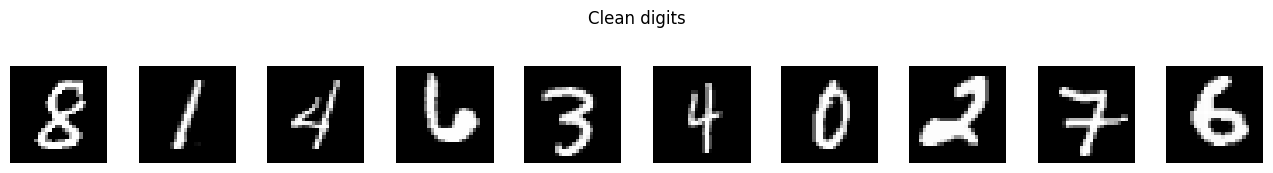

In [4]:
def show_row(batch, title, n=10):
    # plot the first n images of a batch in a single row
    batch = batch[:n].cpu()
    fig, axes = plt.subplots(1, n, figsize=(n * 1.3, 1.6))
    for i, ax in enumerate(axes):
        ax.imshow(batch[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()

clean_batch, _ = next(iter(train_loader))
show_row(clean_batch, "Clean digits")

## 2. Adding noise

To make the noisy inputs I add Gaussian noise to each image and clip back to 0-1 so it stays a valid image:

`noisy = clip(clean + noise_factor * randn, 0, 1)`

A noise_factor of 0.5 felt like a good amount - the digit is clearly corrupted but still readable. The clean image is the target; the noisy one is what the model actually sees.

In [5]:
NOISE_FACTOR = 0.5

def add_noise(imgs, noise_factor=NOISE_FACTOR, generator=None):
    # pass a generator when you want the exact same noise every time (for figures)
    if generator is not None:
        noise = torch.randn(imgs.shape, generator=generator)
    else:
        noise = torch.randn_like(imgs)
    return torch.clamp(imgs + noise_factor * noise, 0.0, 1.0)

noisy_demo = add_noise(clean_batch)
print("noise factor:", NOISE_FACTOR)
print("noisy pixel range after clipping:",
      (round(float(noisy_demo.min()), 2), round(float(noisy_demo.max()), 2)))

noise factor: 0.5
noisy pixel range after clipping: (0.0, 1.0)


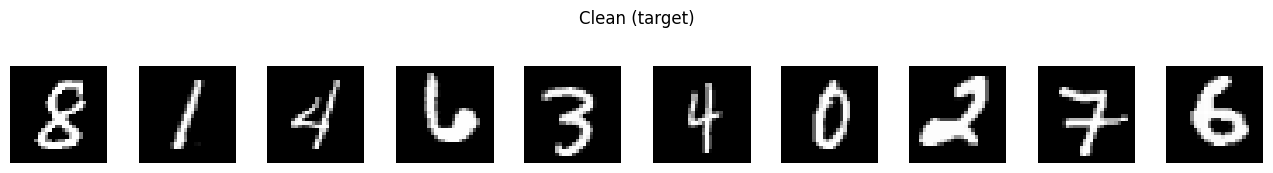

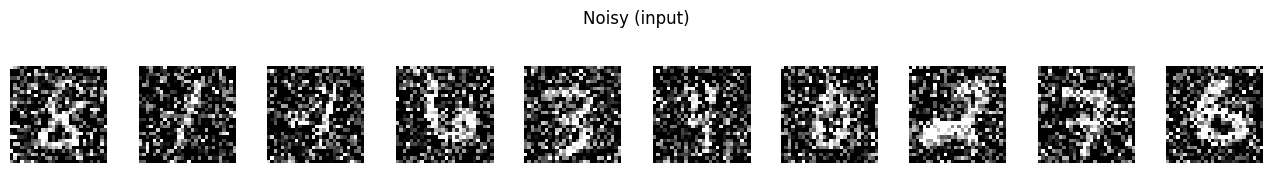

In [6]:
show_row(clean_batch, "Clean (target)")
show_row(noisy_demo,  "Noisy (input)")

## 3. The model

A convolutional autoencoder. The encoder is two conv layers that take the 28x28 image down to 7x7 while going from 1 channel to 64. The decoder mirrors that with two transposed-conv layers back up to 28x28, ending in a sigmoid so the output stays in 0-1.

I put BatchNorm after each conv. My first version without it trained fine for a few epochs and then collapsed - it started giving the same blank-ish image for every input. BatchNorm fixed that (I wrote more about it at the end).

In [7]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),   # 28 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 7 -> 14
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),   # 14 -> 28
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = DenoisingAutoencoder().to(device)
print(model)
print("\ntrainable params:", sum(p.numel() for p in model.parameters()))

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): Sigmoid()
  )
)

trainable params: 37825


## 4. Training

Loss is MSE between the output and the clean image, Adam at 1e-3, for 15 epochs. One thing I did on purpose: generate fresh noise on every batch instead of noising the dataset once up front. That way the model sees a new noise pattern each time and learns to remove noise in general rather than memorizing one fixed pattern. I also track the test loss each epoch to keep an eye on overfitting.

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 15

def run_epoch(loader, train):
    model.train() if train else model.eval()
    total, count = 0.0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for clean, _ in loader:
            clean = clean.to(device)
            noisy = add_noise(clean)                 # fresh noise each batch
            out = model(noisy)
            loss = criterion(out, clean)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total += loss.item() * clean.size(0)
            count += clean.size(0)
    return total / count

In [9]:
history = {"train": [], "test": []}

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    history["train"].append(tr)
    history["test"].append(te)
    print(f"epoch {epoch:2d}   train MSE {tr:.5f}   test MSE {te:.5f}")

epoch  1   train MSE 0.02659   test MSE 0.01338
epoch  2   train MSE 0.01292   test MSE 0.01232
epoch  3   train MSE 0.01228   test MSE 0.01197
epoch  4   train MSE 0.01196   test MSE 0.01169
epoch  5   train MSE 0.01176   test MSE 0.01157
epoch  6   train MSE 0.01162   test MSE 0.01159
epoch  7   train MSE 0.01157   test MSE 0.01136
epoch  8   train MSE 0.01150   test MSE 0.01127
epoch  9   train MSE 0.01144   test MSE 0.01128
epoch 10   train MSE 0.01138   test MSE 0.01122
epoch 11   train MSE 0.01134   test MSE 0.01119
epoch 12   train MSE 0.01132   test MSE 0.01114
epoch 13   train MSE 0.01128   test MSE 0.01114
epoch 14   train MSE 0.01122   test MSE 0.01109
epoch 15   train MSE 0.01123   test MSE 0.01107


Loss curve - I want both lines going down together, which means it's learning without overfitting.

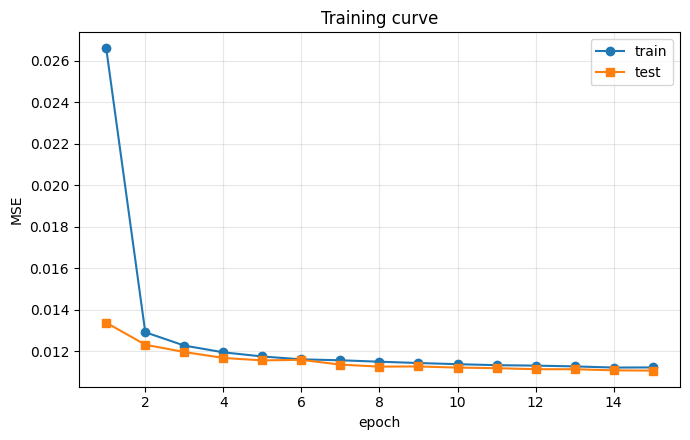

In [10]:
plt.figure(figsize=(7, 4.5))
xs = range(1, EPOCHS + 1)
plt.plot(xs, history["train"], "o-", label="train")
plt.plot(xs, history["test"],  "s-", label="test")
plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("Training curve")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Saving the trained weights so the model can be reloaded later without retraining.

In [11]:
torch.save(model.state_dict(), "denoising_autoencoder.pth")
print("saved weights to denoising_autoencoder.pth")

# to reload later:
# model.load_state_dict(torch.load("denoising_autoencoder.pth", map_location=device))

saved weights to denoising_autoencoder.pth


## 5. Results on the test set

Now the interesting part - run the trained model on test digits it hasn't seen. I use a fixed noise seed here so the figure comes out the same each time. Three rows: the original clean digit, the noisy version the model gets, and what it gives back.

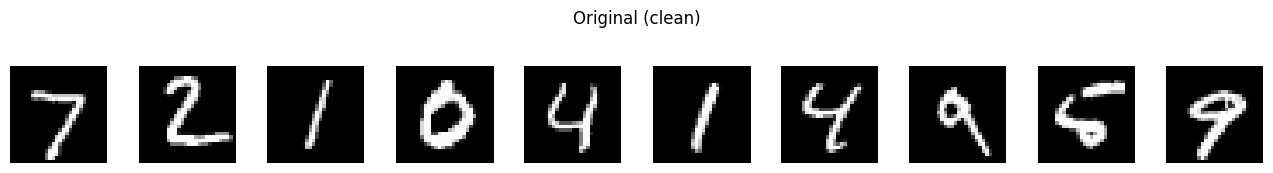

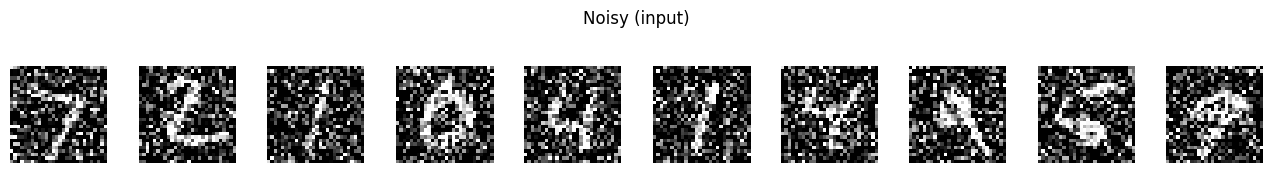

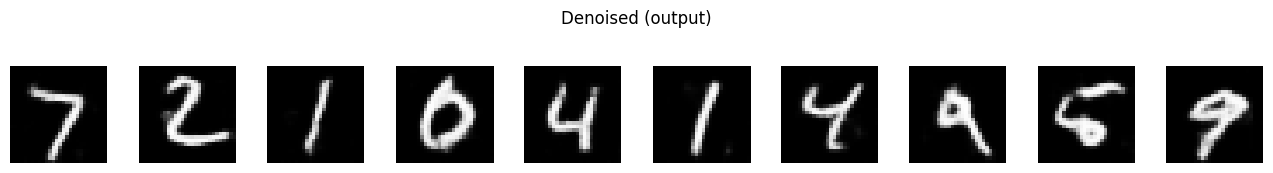

In [12]:
test_clean, _ = next(iter(test_loader))
viz_gen = torch.Generator().manual_seed(SEED)       # fixed noise -> repeatable figure
test_noisy = add_noise(test_clean, generator=viz_gen)

model.eval()
with torch.no_grad():
    test_denoised = model(test_noisy.to(device)).cpu()

show_row(test_clean,    "Original (clean)")
show_row(test_noisy,    "Noisy (input)")
show_row(test_denoised, "Denoised (output)")

## 6. Measuring quality: PSNR and SSIM

Eyeballing the images is fine but I wanted actual numbers. Two standard ones:

- PSNR (in dB) comes straight from the MSE - higher is better.
- SSIM measures how structurally similar two images are, from 0 to 1 (1 = identical).

skimage isn't there on a fresh Colab, so I wrote SSIM myself with an 11x11 Gaussian window. I compute both metrics for the noisy images and for the denoised ones (each compared against the clean original), averaged over all 10,000 test images.

In [13]:
def psnr(x, y, max_val=1.0):
    # peak signal-to-noise ratio, per image, for batches in [0,1]
    mse = F.mse_loss(x, y, reduction="none").mean(dim=[1, 2, 3]).clamp(min=1e-10)
    return 10.0 * torch.log10(max_val ** 2 / mse)

def gaussian_window(size=11, sigma=1.5):
    coords = torch.arange(size).float() - size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    w = g[:, None] @ g[None, :]
    return w[None, None, :, :]

SSIM_WINDOW = gaussian_window()

def ssim(x, y, window=SSIM_WINDOW, C1=0.01 ** 2, C2=0.03 ** 2):
    # structural similarity, per image, for batches in [0,1]
    w = window.to(x.device)
    pad = w.shape[-1] // 2
    mu_x = F.conv2d(x, w, padding=pad)
    mu_y = F.conv2d(y, w, padding=pad)
    mu_x2, mu_y2, mu_xy = mu_x ** 2, mu_y ** 2, mu_x * mu_y
    var_x = F.conv2d(x * x, w, padding=pad) - mu_x2
    var_y = F.conv2d(y * y, w, padding=pad) - mu_y2
    cov   = F.conv2d(x * y, w, padding=pad) - mu_xy
    smap = ((2 * mu_xy + C1) * (2 * cov + C2)) / ((mu_x2 + mu_y2 + C1) * (var_x + var_y + C2))
    return smap.mean(dim=[1, 2, 3])

In [14]:
torch.manual_seed(SEED)
model.eval()
sums = {"psnr_noisy": 0.0, "psnr_out": 0.0, "ssim_noisy": 0.0, "ssim_out": 0.0}
count = 0
with torch.no_grad():
    for clean, _ in test_loader:
        clean = clean.to(device)
        noisy = add_noise(clean)
        out = model(noisy)
        count += clean.size(0)
        sums["psnr_noisy"] += psnr(noisy, clean).sum().item()
        sums["psnr_out"]   += psnr(out,   clean).sum().item()
        sums["ssim_noisy"] += ssim(noisy, clean).sum().item()
        sums["ssim_out"]   += ssim(out,   clean).sum().item()

avg = {k: v / count for k, v in sums.items()}
print(f"PSNR:  noisy {avg['psnr_noisy']:.2f} dB  ->  denoised {avg['psnr_out']:.2f} dB")
print(f"SSIM:  noisy {avg['ssim_noisy']:.3f}  ->  denoised {avg['ssim_out']:.3f}")

PSNR:  noisy 9.38 dB  ->  denoised 19.88 dB
SSIM:  noisy 0.211  ->  denoised 0.870


## 7. Comparison with classical denoisers

Is the autoencoder actually doing better than something simple? To have a fair reference I compare it against two classic filters run on the same noisy images: a 5x5 Gaussian blur and a 3x3 median filter. Both are common quick ways to smooth out noise. I score all of them with PSNR/SSIM over the test set and line the autoencoder up next to them.

In [15]:
def gaussian_blur(x, size=5, sigma=1.0):
    w = gaussian_window(size, sigma).to(x.device)
    return F.conv2d(x, w, padding=size // 2)

def median_filter(x, k=3):
    # 3x3 median: gather each pixel's neighbourhood and take the median
    pad = k // 2
    xp = F.pad(x, (pad, pad, pad, pad), mode="reflect")
    patches = xp.unfold(2, k, 1).unfold(3, k, 1)          # N,C,H,W,k,k
    patches = patches.contiguous().view(*patches.shape[:4], -1)
    return patches.median(dim=-1).values

def show_compare(rows, n=8):
    # rows: list of (label, batch); shows the first n images of each on its own line
    fig, axes = plt.subplots(len(rows), n, figsize=(n * 1.2, len(rows) * 1.2))
    for r, (label, batch) in enumerate(rows):
        for col in range(n):
            ax = axes[r, col]
            ax.imshow(batch[col].squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
        axes[r, 0].set_ylabel(label, rotation=0, ha="right", va="center")
    plt.tight_layout()
    plt.show()

In [16]:
scores = {m: {"psnr": 0.0, "ssim": 0.0}
          for m in ["noisy", "gaussian blur", "median filter", "autoencoder"]}
count = 0
torch.manual_seed(SEED)
model.eval()
with torch.no_grad():
    for clean, _ in test_loader:
        clean = clean.to(device)
        noisy = add_noise(clean)
        outputs = {
            "noisy":         noisy,
            "gaussian blur": gaussian_blur(noisy),
            "median filter": median_filter(noisy),
            "autoencoder":   model(noisy),
        }
        count += clean.size(0)
        for m, o in outputs.items():
            scores[m]["psnr"] += psnr(o, clean).sum().item()
            scores[m]["ssim"] += ssim(o, clean).sum().item()

print(f"{'method':<16}{'PSNR (dB)':>11}{'SSIM':>9}")
for m in scores:
    print(f"{m:<16}{scores[m]['psnr']/count:>11.2f}{scores[m]['ssim']/count:>9.3f}")

method            PSNR (dB)     SSIM
noisy                  9.38    0.211
gaussian blur         12.65    0.219
median filter         14.19    0.317
autoencoder           19.88    0.870


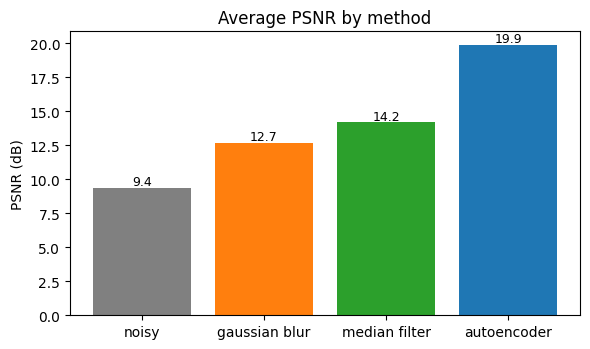

In [17]:
# PSNR as a quick bar chart
names = list(scores)
psnrs = [scores[m]["psnr"] / count for m in names]
plt.figure(figsize=(6, 3.6))
bars = plt.bar(names, psnrs, color=["gray", "tab:orange", "tab:green", "tab:blue"])
for b, p in zip(bars, psnrs):
    plt.text(b.get_x() + b.get_width() / 2, p + 0.2, f"{p:.1f}", ha="center", fontsize=9)
plt.ylabel("PSNR (dB)"); plt.title("Average PSNR by method")
plt.tight_layout(); plt.show()

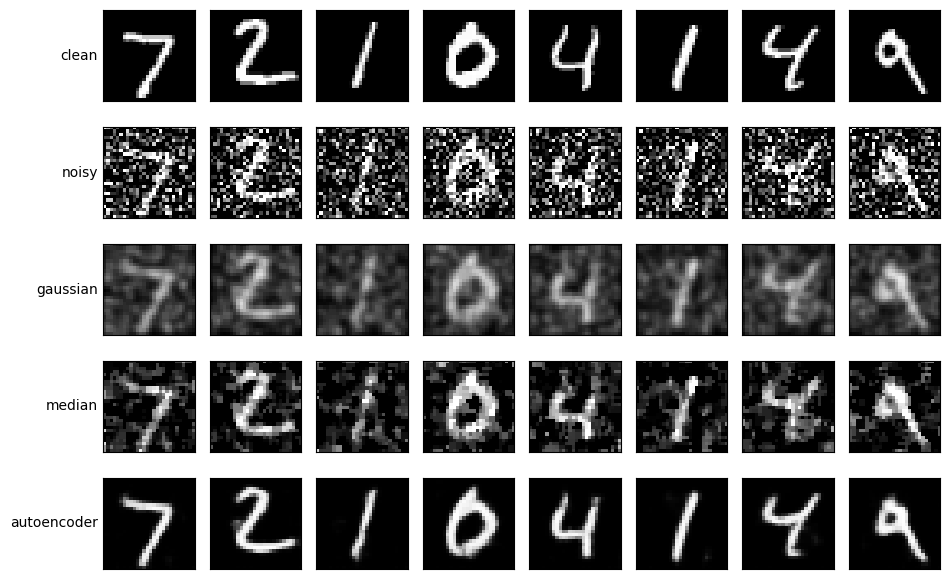

In [18]:
# same digits through each method
with torch.no_grad():
    g_out = gaussian_blur(test_noisy.to(device))
    m_out = median_filter(test_noisy.to(device))

show_compare([
    ("clean",       test_clean),
    ("noisy",       test_noisy),
    ("gaussian",    g_out),
    ("median",      m_out),
    ("autoencoder", test_denoised),
])

The autoencoder comes out well ahead on both metrics - 19.88 dB versus 14.19 dB for the median filter and 12.65 dB for the Gaussian blur. The Gaussian blur removes noise but also smears the strokes, and the median filter keeps edges a bit better but leaves speckle behind. The autoencoder is the only one that removes the noise and keeps the digit looking like a clean digit, which makes sense - it learned what MNIST digits are supposed to look like, while the filters just average nearby pixels.

## 8. Where it does well and where it struggles

To see the failure modes I took the first 2000 test images, ranked them by PSNR after denoising, and pulled out the easiest and hardest ones. The best cases are clean, confident recoveries; the worst ones are usually messy or oddly-written digits where even a person might hesitate.

In [19]:
N = 2000
c_list, n_list, d_list = [], [], []
seen = 0
noise_gen = torch.Generator().manual_seed(SEED)
model.eval()
with torch.no_grad():
    for clean, _ in test_loader:
        take = min(clean.size(0), N - seen)
        clean = clean[:take]
        noisy = add_noise(clean, generator=noise_gen)     # clean is on CPU here
        out = model(noisy.to(device)).cpu()
        c_list.append(clean); n_list.append(noisy); d_list.append(out)
        seen += take
        if seen >= N:
            break

clean_all = torch.cat(c_list); noisy_all = torch.cat(n_list); deno_all = torch.cat(d_list)
per_psnr = psnr(deno_all, clean_all)
order = torch.argsort(per_psnr, descending=True)
best, worst = order[:8], order[-8:].flip(0)
print(f"over {N} images -> best {per_psnr[best[0]]:.1f} dB, "
      f"worst {per_psnr[worst[0]]:.1f} dB, mean {per_psnr.mean():.1f} dB")

over 2000 images -> best 27.2 dB, worst 15.0 dB, mean 19.9 dB


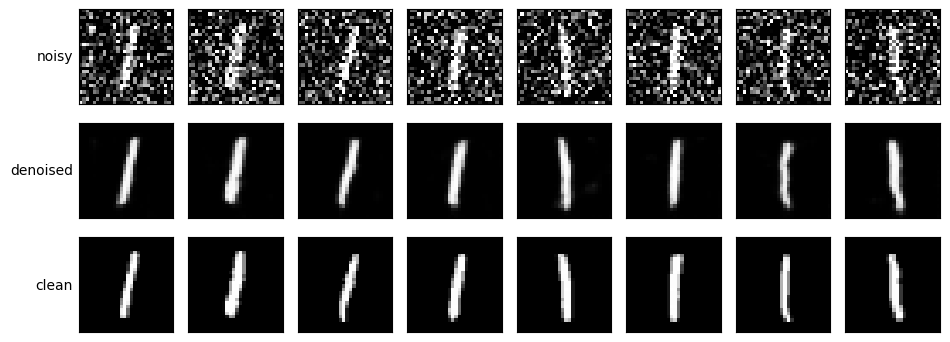

Best reconstructions (highest PSNR)


In [20]:
show_compare([("noisy", noisy_all[best]),
              ("denoised", deno_all[best]),
              ("clean", clean_all[best])])
print("Best reconstructions (highest PSNR)")

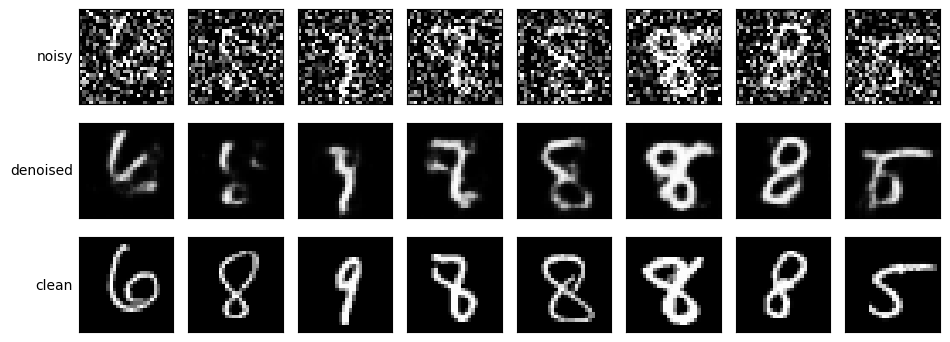

Worst reconstructions (lowest PSNR)


In [21]:
show_compare([("noisy", noisy_all[worst]),
              ("denoised", deno_all[worst]),
              ("clean", clean_all[worst])])
print("Worst reconstructions (lowest PSNR)")

The hard cases are telling: they're mostly loopy, closed-loop digits - a lot of 8s, with some 5s, 6s and 9s. Those pack the most shape into a small space, so once the noise blurs the loops it gets ambiguous which digit it is, and the model reconstructs a plausible but slightly wrong version. That lines up with the small amount of blur seen everywhere else.

## 9. Robustness across noise levels

The model only ever saw noise_factor 0.5 during training. I was curious how it handles lighter and heavier noise, so I ran the test set through it at a range of noise levels and measured PSNR/SSIM at each.

In [22]:
noise_levels = [0.2, 0.4, 0.5, 0.6, 0.8]
sweep = {"level": [], "psnr": [], "ssim": []}

model.eval()
for nf in noise_levels:
    torch.manual_seed(SEED)
    p_sum, s_sum, n = 0.0, 0.0, 0
    with torch.no_grad():
        for clean, _ in test_loader:
            clean = clean.to(device)
            out = model(add_noise(clean, nf))
            n += clean.size(0)
            p_sum += psnr(out, clean).sum().item()
            s_sum += ssim(out, clean).sum().item()
    sweep["level"].append(nf)
    sweep["psnr"].append(p_sum / n)
    sweep["ssim"].append(s_sum / n)
    tag = "  (trained here)" if nf == NOISE_FACTOR else ""
    print(f"noise {nf}:  PSNR {p_sum/n:.2f} dB   SSIM {s_sum/n:.3f}{tag}")

noise 0.2:  PSNR 24.12 dB   SSIM 0.958
noise 0.4:  PSNR 21.47 dB   SSIM 0.922
noise 0.5:  PSNR 19.88 dB   SSIM 0.870  (trained here)
noise 0.6:  PSNR 18.10 dB   SSIM 0.768
noise 0.8:  PSNR 14.71 dB   SSIM 0.527


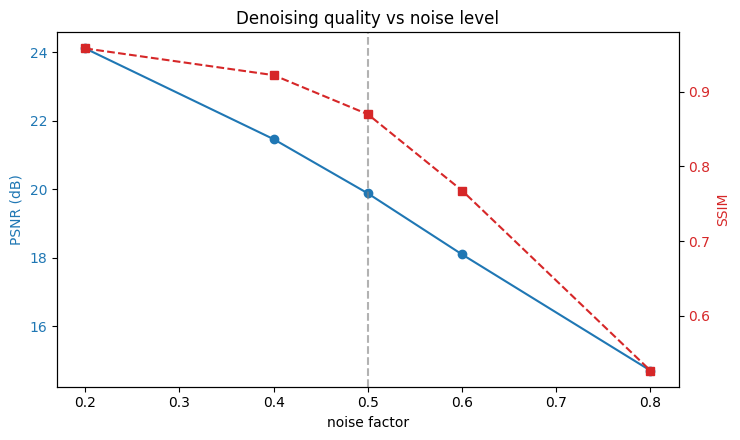

In [23]:
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax1.plot(sweep["level"], sweep["psnr"], "o-", color="tab:blue", label="PSNR")
ax1.set_xlabel("noise factor")
ax1.set_ylabel("PSNR (dB)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.axvline(NOISE_FACTOR, ls="--", color="gray", alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(sweep["level"], sweep["ssim"], "s--", color="tab:red", label="SSIM")
ax2.set_ylabel("SSIM", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Denoising quality vs noise level")
fig.tight_layout(); plt.show()

Same digit denoised at each level - top row is the noisy input, bottom row is what the model gives back.

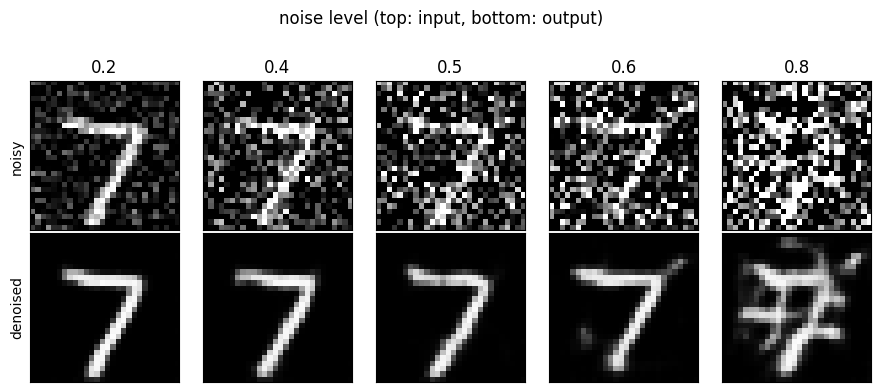

In [24]:
one = test_clean[0:1]   # a single test digit
fig, axes = plt.subplots(2, len(noise_levels), figsize=(len(noise_levels) * 1.8, 3.8))
for j, nf in enumerate(noise_levels):
    gen = torch.Generator().manual_seed(SEED + j)
    noisy = add_noise(one, nf, generator=gen)
    with torch.no_grad():
        out = model(noisy.to(device)).cpu()
    for ax, im in [(axes[0, j], noisy), (axes[1, j], out)]:
        ax.imshow(im.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])   # hide ticks but keep the row labels visible
    axes[0, j].set_title(str(nf))
axes[0, 0].set_ylabel("noisy")
axes[1, 0].set_ylabel("denoised")
fig.suptitle("noise level (top: input, bottom: output)", y=1.02)
plt.tight_layout(); plt.show()

## 10. What the encoder learned

The encoder turns each image into a 64x7x7 code. If that code really captures the digit, then images of the same digit should end up near each other in it. I encoded 2000 clean test images, squeezed the codes down to 2D (PCA then t-SNE), and colored each point by its true label. Clear per-digit clusters would mean the compressed representation carries the digit structure - the same structure the decoder leans on to rebuild a clean image from a noisy one.

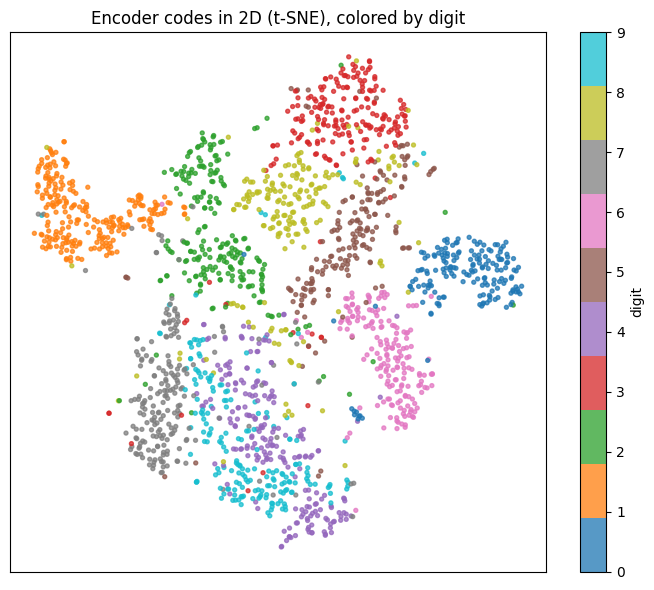

In [25]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# encode a subset of clean test images
Nz = 2000
xs, ys = [], []
for x, y in test_loader:
    xs.append(x); ys.append(y)
    if sum(t.size(0) for t in xs) >= Nz:
        break
xs = torch.cat(xs)[:Nz]
labels = torch.cat(ys)[:Nz].numpy()

model.eval()
with torch.no_grad():
    codes = model.encoder(xs.to(device)).cpu().flatten(1).numpy()

codes50 = PCA(n_components=50, random_state=SEED).fit_transform(codes)
codes2d = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30).fit_transform(codes50)

plt.figure(figsize=(7, 6))
sc = plt.scatter(codes2d[:, 0], codes2d[:, 1], c=labels, cmap="tab10", s=8, alpha=0.75)
plt.colorbar(sc, ticks=range(10), label="digit")
plt.title("Encoder codes in 2D (t-SNE), colored by digit")
plt.xticks([]); plt.yticks([])
plt.tight_layout(); plt.show()

The digits mostly separate into their own groups, with the usual overlaps you'd expect (things like 4/9 and 3/5/8 sitting close). So even though the network was only ever asked to clean up images, the middle layer ended up organizing them by identity on its own - which is exactly why it can keep the right shape while dropping the noise.

## 11. Improving it with skip connections

The one thing I wasn't happy with above is the slight blur. The plain autoencoder has to squeeze everything through the 7x7 bottleneck, so fine detail gets lost on the way back up. The usual fix for this is skip connections (the U-Net idea): the decoder is handed the matching encoder feature maps directly, so it can put back sharp edges without depending on the bottleneck alone. I built that version, trained it the same way, and compared it to the base model.

In [26]:
class UNetDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        def cbr(i, o):   # conv + batchnorm + relu, keeps the spatial size
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(True))
        self.e1 = cbr(1, 32)
        self.down1 = nn.Conv2d(32, 32, 3, stride=2, padding=1)   # 28 -> 14
        self.e2 = cbr(32, 64)
        self.down2 = nn.Conv2d(64, 64, 3, stride=2, padding=1)   # 14 -> 7
        self.bottleneck = cbr(64, 64)
        self.up2 = nn.ConvTranspose2d(64, 64, 3, stride=2, padding=1, output_padding=1)  # 7 -> 14
        self.merge2 = cbr(128, 64)                               # after concat with e2
        self.up1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)  # 14 -> 28
        self.merge1 = cbr(64, 32)                                # after concat with e1
        self.out = nn.Sequential(nn.Conv2d(32, 1, 3, padding=1), nn.Sigmoid())

    def forward(self, x):
        c1 = self.e1(x)                              # 32 x 28 x 28
        c2 = self.e2(F.relu(self.down1(c1)))         # 64 x 14 x 14
        b  = self.bottleneck(F.relu(self.down2(c2))) # 64 x 7 x 7
        u2 = self.merge2(torch.cat([self.up2(b),  c2], dim=1))   # skip connection from c2
        u1 = self.merge1(torch.cat([self.up1(u2), c1], dim=1))   # skip connection from c1
        return self.out(u1)

unet = UNetDenoiser().to(device)
print("skip-connection model params:", sum(p.numel() for p in unet.parameters()))

skip-connection model params: 250369


In [27]:
opt_u = torch.optim.Adam(unet.parameters(), lr=1e-3)

for epoch in range(1, EPOCHS + 1):
    unet.train()
    total, count = 0.0, 0
    for clean, _ in train_loader:
        clean = clean.to(device)
        loss = criterion(unet(add_noise(clean)), clean)
        opt_u.zero_grad(); loss.backward(); opt_u.step()
        total += loss.item() * clean.size(0); count += clean.size(0)
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:2d}   train MSE {total/count:.5f}")

epoch  1   train MSE 0.01325
epoch  5   train MSE 0.00872
epoch 10   train MSE 0.00831
epoch 15   train MSE 0.00814


In [28]:
# score the skip model on the test set and put it next to the base model
torch.manual_seed(SEED)
unet.eval()
pu, su, nu = 0.0, 0.0, 0
with torch.no_grad():
    for clean, _ in test_loader:
        clean = clean.to(device)
        out = unet(add_noise(clean))
        pu += psnr(out, clean).sum().item()
        su += ssim(out, clean).sum().item()
        nu += clean.size(0)

print(f"{'model':<22}{'PSNR (dB)':>11}{'SSIM':>9}")
print(f"{'base autoencoder':<22}{avg['psnr_out']:>11.2f}{avg['ssim_out']:>9.3f}")
print(f"{'+ skip connections':<22}{pu/nu:>11.2f}{su/nu:>9.3f}")

model                   PSNR (dB)     SSIM
base autoencoder            19.88    0.870
+ skip connections          21.28    0.912


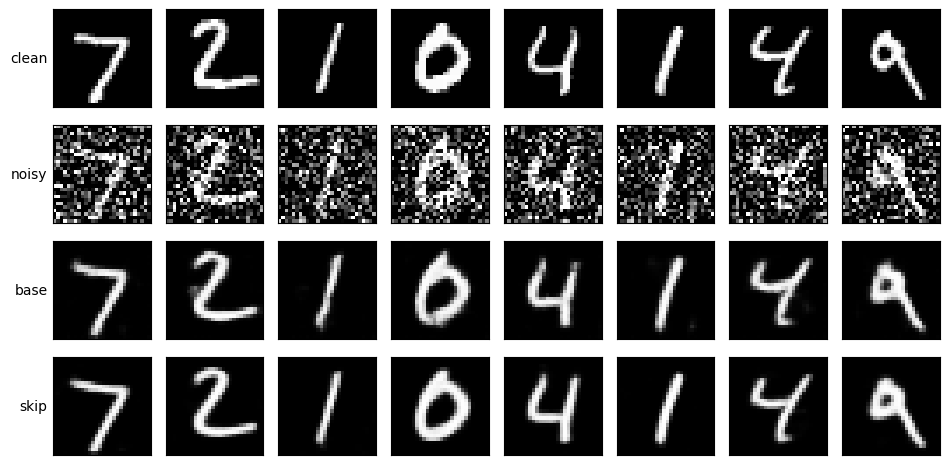

In [29]:
# same digits: base output vs skip-connection output
with torch.no_grad():
    unet_out = unet(test_noisy.to(device))

show_compare([
    ("clean", test_clean),
    ("noisy", test_noisy),
    ("base",  test_denoised),
    ("skip",  unet_out),
])

The skip-connection model comes out ahead: 21.28 dB / 0.913, compared with 19.88 dB / 0.870 for the base model, and you can see it in the images - the strokes are sharper and closer to the originals, with less of the smudging. It costs more parameters (about 250k vs 38k), but for MNIST that's an easy trade.

## 12. Observations

The model works well overall. The main things I noticed from the results:

- PSNR went from 9.38 dB on the noisy images to 19.88 dB after denoising, and SSIM from 0.211 to 0.870 - both big jumps.
- It clearly beat the classical filters: the best of them, the 3x3 median filter, managed 14.19 dB against the autoencoder's 19.88 dB. So it is doing more than averaging nearby pixels - it learned what a digit should look like.
- The outputs are a bit blurry because the 7x7 bottleneck drops fine detail. The skip-connection version in section 11 recovered a lot of that sharpness and pushed the numbers up to 21.28 dB / 0.913.
- The hardest cases (the lowest was about 14.9 dB) are the loopy, closed-loop digits - a lot of 8s, with some 5s, 6s and 9s. Once the noise blurs the loops their exact shape gets ambiguous, so the model rebuilds a close but slightly wrong version.
- It still works at noise levels it never trained on. The scores are highest on the lightest noise (24.11 dB at 0.2) and drop steadily as the noise gets stronger (down to 14.72 dB at 0.8) - but even there it is clearly still denoising, so it generalized past the single 0.5 level it trained on.
- The encoder learned digit identity on its own. In the t-SNE plot the codes group cleanly by digit, even though the model was only ever asked to clean up images.

The main challenge was training stability. Without BatchNorm the model collapsed after a few good epochs - every output turned into the same blank image, no matter the input. The clue was the noise sweep giving identical numbers at every level, which only happens when the output ignores the input. Adding BatchNorm after each conv fixed it. Two smaller things also mattered: output_padding=1 so the decoder gets back to exactly 28x28, and a sigmoid output paired with 0-1 targets so the MSE loss behaves.

Putting it together, the autoencoder removes the noise while keeping the digit structure, the PSNR and SSIM numbers back up what the images show, and the skip-connection version pushes the quality further still - so the model does what the task set out to do.